![header](content/img/header.PNG)


# Part 6 : Download and plot seasonal forecast using earthkit


- Download and explore discharge seasonal forecast files
- Aggregate discharge daily seasonal forecast into monthly means
- Create discharge forecast maps for a selected target month
- Plot discharge ensemble seasonal forecasts (Fan plot)
- Aggregate the daily seasonal forecast into monthly means and Create forecast maps for the Soil Wetness Index

## Download and explore the seasonal forecast files

In [6]:
import earthkit as ekh
import earthkit.data as ekd

In [ ]:
# Morocco domain [North, West, South, East]
BBOX_MOROCCO = [36.20, -17.50, 20.50, -0.50]

DATASET = 'cems-glofas-seasonal'
LEADTIMES = ['%d' % (l) for l in range(24, 2976, 24)]
REQUEST = {
    'system_version': ['operational'],
    "hydrological_model": ["lisflood"],
    'variable': 'river_discharge_in_the_last_24_hours',
    'year': ["2026"],
    'month': ["01"],
    'leadtime_hour': LEADTIMES,
    'area': BBOX_MOROCCO,
    'data_format': 'grib2', # Or netcdf
    'download_format': 'unarchived'
        }
#data=ekh.data.from_source('cds',DATASET,REQUEST)
# this takes 6 mins so we might want to reduce
data = ekd.from_source("cds",DATASET,  request=REQUEST)

2026-07-01 13:07:33,752 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
2026-07-01 13:07:33,752 INFO Request ID is f33a38bd-6977-45cb-8fab-4627e5cc6189
2026-07-01 13:07:33,772 INFO status has been updated to accepted


In [2]:
data = ekh.data.from_source("file","/perm/ecm3644/ecmwf-training/WMO-Seasonal/seasonal-data-spain/cems-glofas-seasonal_2024_08.grib")

### Loop over the data object (Messages)

In [3]:
for i in data:
    print(i)

GribField(dis24,None,20240801,0,24,0)
GribField(dis24,None,20240801,0,24,1)
GribField(dis24,None,20240801,0,24,2)
GribField(dis24,None,20240801,0,24,3)
GribField(dis24,None,20240801,0,24,4)
GribField(dis24,None,20240801,0,24,5)
GribField(dis24,None,20240801,0,24,6)
GribField(dis24,None,20240801,0,24,7)
GribField(dis24,None,20240801,0,24,8)
GribField(dis24,None,20240801,0,24,9)
GribField(dis24,None,20240801,0,24,10)
GribField(dis24,None,20240801,0,24,11)
GribField(dis24,None,20240801,0,24,12)
GribField(dis24,None,20240801,0,24,13)
GribField(dis24,None,20240801,0,24,14)
GribField(dis24,None,20240801,0,24,15)
GribField(dis24,None,20240801,0,24,16)
GribField(dis24,None,20240801,0,24,17)
GribField(dis24,None,20240801,0,24,18)
GribField(dis24,None,20240801,0,24,19)
GribField(dis24,None,20240801,0,24,20)
GribField(dis24,None,20240801,0,24,21)
GribField(dis24,None,20240801,0,24,22)
GribField(dis24,None,20240801,0,24,23)
GribField(dis24,None,20240801,0,24,24)
GribField(dis24,None,20240801,0,24,

### Lenght of data object

In [4]:
len(data)

6273

### Check the metadata keys with ls()

In [6]:
data.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
0,ecmf,dis24,surface,0,20240801,0,0-24,fc,0,regular_ll
1,ecmf,dis24,surface,0,20240801,0,0-24,fc,1,regular_ll
2,ecmf,dis24,surface,0,20240801,0,0-24,fc,2,regular_ll
3,ecmf,dis24,surface,0,20240801,0,0-24,fc,3,regular_ll
4,ecmf,dis24,surface,0,20240801,0,0-24,fc,4,regular_ll
...,...,...,...,...,...,...,...,...,...,...
6268,ecmf,dis24,surface,0,20240801,0,2928-2952,fc,46,regular_ll
6269,ecmf,dis24,surface,0,20240801,0,2928-2952,fc,47,regular_ll
6270,ecmf,dis24,surface,0,20240801,0,2928-2952,fc,48,regular_ll
6271,ecmf,dis24,surface,0,20240801,0,2928-2952,fc,49,regular_ll


### Check mars archive keys with describe()

In [7]:
data.describe()

,,level,date,time,step,number,paramId,class,stream,type,experimentVersionNumber
shortName,typeOfLevel,,,,,,,,,,
dis24,surface,0,20240801,0,"1536,1032,...","0,1,...",240024,ce,wfse,fc,0001


### Check mars namespace keys of one message with dump()

In [8]:
data[0].dump()

globalDomain,g
GRIBEditionNumber,2
tablesVersionLatestOfficial,35
tablesVersionLatest,35
grib2divider,1000000
angleSubdivisions,1000000
missingValue,9999
ieeeFloats,1
isHindcast,0
section0Length,16
identifier,GRIB


### Quick plot of the first message (step 1, member =0)

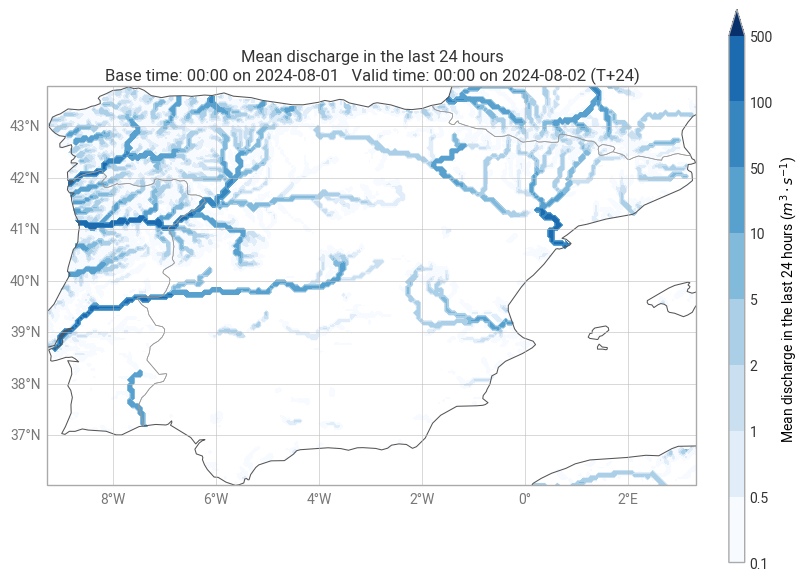

In [9]:
style = ekh.plots.styles.Style(
    colors="Blues",
    levels=[0.1, 0.5, 1, 2, 5, 10, 50, 100, 500],
    extend="max",
    units="m**3 s-1",
)
chart = ekh.plots.Map()

chart.quickplot(data[0], style=style)

chart.title()
chart.legend(location="right")

chart.coastlines()
chart.borders()
chart.gridlines()

chart.show()

## Aggregate the daily seasonal forecast into monthly means

### Converting the fieldlist to xarray 

In [10]:
data_array=data.to_xarray(engine='earthkit',time_dim_mode="valid_time")
print(data_array)

<xarray.Dataset> Size: 2GB
Dimensions:     (number: 51, valid_time: 123, latitude: 156, longitude: 253)
Coordinates:
  * number      (number) int64 408B 0 1 2 3 4 5 6 7 ... 43 44 45 46 47 48 49 50
  * valid_time  (valid_time) datetime64[ns] 984B 2024-08-02 ... 2024-12-02
  * latitude    (latitude) float64 1kB 43.77 43.73 43.68 ... 36.13 36.08 36.02
  * longitude   (longitude) float64 2kB -9.275 -9.225 -9.175 ... 3.275 3.325
Data variables:
    dis24       (number, valid_time, latitude, longitude) float64 2GB ...
Attributes: (12/14)
    param:        dis24
    paramId:      240024
    class:        ce
    stream:       wfse
    levtype:      sfc
    type:         fc
    ...           ...
    time:         0
    anoffset:     0
    origin:       ecmf
    domain:       g
    Conventions:  CF-1.8
    institution:  ECMWF


### Using earthkit transform method .temporal.monthly_reduce to compute the monthly means

In [12]:
data_array_transform=ekh.transforms.temporal.monthly_reduce(data_array,time_dim='valid_time')

In [13]:
data_array_transform

<xarray.Dataset> Size: 81MB
Dimensions:     (valid_time: 5, number: 51, latitude: 156, longitude: 253)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 40B 2024-08-01 ... 2024-12-01
  * number      (number) int64 408B 0 1 2 3 4 5 6 7 ... 43 44 45 46 47 48 49 50
  * latitude    (latitude) float64 1kB 43.77 43.73 43.68 ... 36.13 36.08 36.02
  * longitude   (longitude) float64 2kB -9.275 -9.225 -9.175 ... 3.275 3.325
Data variables:
    dis24       (valid_time, number, latitude, longitude) float64 81MB nan .....
Attributes: (12/14)
    param:        dis24
    paramId:      240024
    class:        ce
    stream:       wfse
    levtype:      sfc
    type:         fc
    ...           ...
    time:         0
    anoffset:     0
    origin:       ecmf
    domain:       g
    Conventions:  CF-1.8
    institution:  ECMWF

In [14]:
data_array_transform.valid_time.values

array(['2024-08-01T00:00:00.000000000', '2024-09-01T00:00:00.000000000',
       '2024-10-01T00:00:00.000000000', '2024-11-01T00:00:00.000000000',
       '2024-12-01T00:00:00.000000000'], dtype='datetime64[ns]')

### Compute the ensemble mean of the monthly means

In [15]:
data_array_transform_ensemble=ekh.transforms.ensemble.mean(data_array_transform)

In [16]:
data_array_transform_ensemble

<xarray.Dataset> Size: 2MB
Dimensions:     (latitude: 156, longitude: 253, valid_time: 5)
Coordinates:
  * latitude    (latitude) float64 1kB 43.77 43.73 43.68 ... 36.13 36.08 36.02
  * longitude   (longitude) float64 2kB -9.275 -9.225 -9.175 ... 3.275 3.325
  * valid_time  (valid_time) datetime64[ns] 40B 2024-08-01 ... 2024-12-01
Data variables:
    dis24       (valid_time, latitude, longitude) float64 2MB nan ... 0.01072
Attributes: (12/14)
    param:        dis24
    paramId:      240024
    class:        ce
    stream:       wfse
    levtype:      sfc
    type:         fc
    ...           ...
    time:         0
    anoffset:     0
    origin:       ecmf
    domain:       g
    Conventions:  CF-1.8
    institution:  ECMWF

### Investigate with a quick plot

/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/earthkit/plots/metadata/labels.py:262: UserWarning: No key "variable_name" found in layer metadata.
  warnings.warn(f'No key "{attr}" found in layer metadata.')


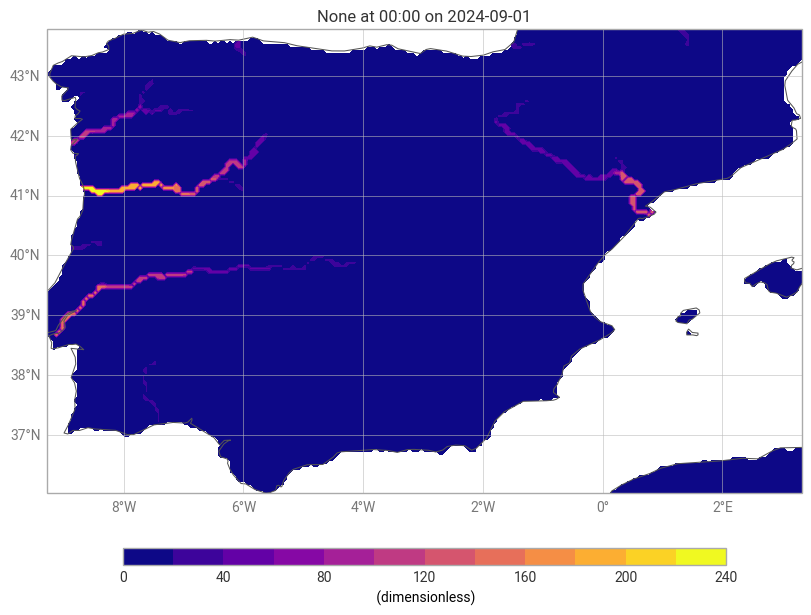

In [17]:
ekh.plots.quickplot(data_array_transform_ensemble.isel(valid_time=1))

## Create forecast maps for a target month (August-2024)

### Subplot of the monthly means of the 51 members over spain

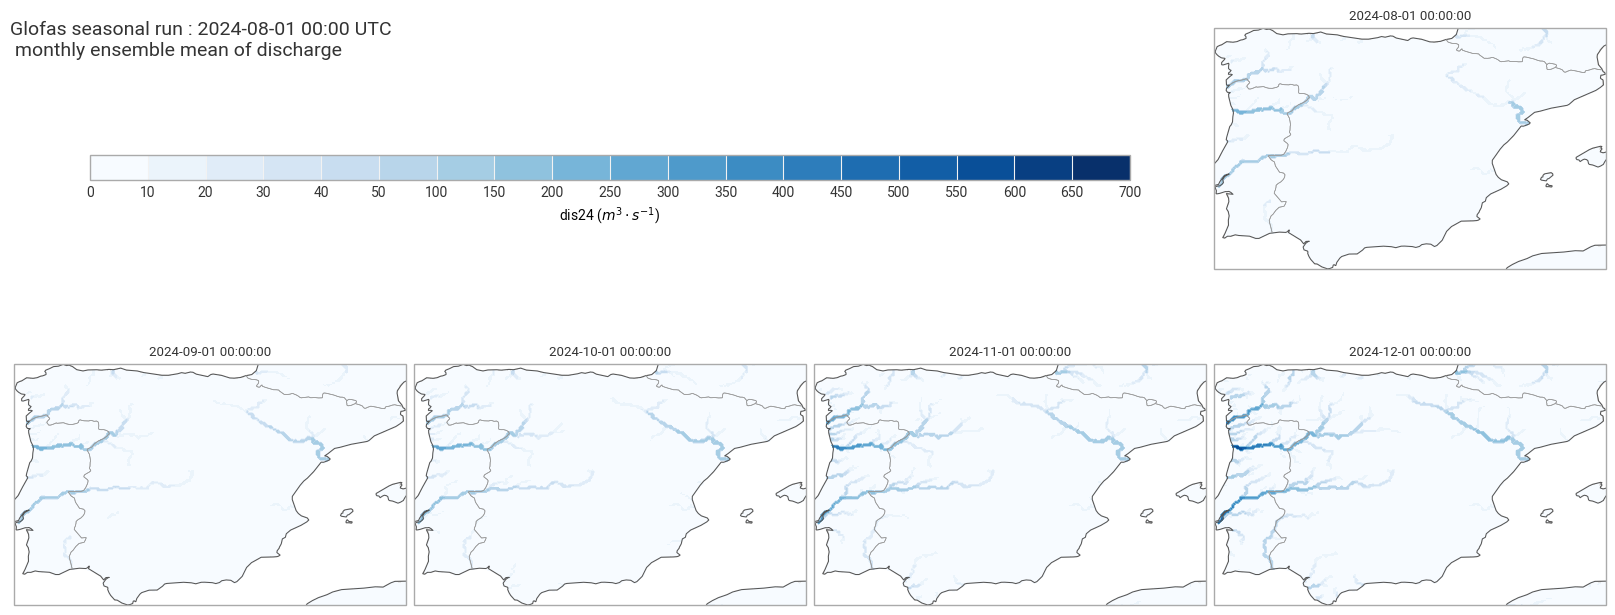

In [18]:
import matplotlib.pyplot as plt

figure = ekh.plots.Figure(rows=3, columns=4,size=(16, 10))
gust_style = ekh.plots.styles.Style(
    levels=[0,10,20,30,40,50, 100, 150, 200, 250, 300, 350,400,450,500,550,600,650,700],
    colors="Blues",
    units="m**3 s-1",
)
figure.add_map(0, 3)
for i in range(4):
    figure.add_map(1+i//4, i%4)

figure.quickplot(data_array_transform_ensemble['dis24'],style=gust_style)



figure.land()
figure.coastlines()
figure.borders()


ax = plt.axes((0.05, 0.8, 0.65, 0.025))
figure.legend(ax=ax)
figure.subplot_titles("{valid_time}")
figure.title(
    "Glofas seasonal run : 2024-08-01 00:00 UTC\n monthly ensemble mean of discharge",
    fontsize=14, horizontalalignment="left", x=0, y=0.96,
)
figure.show()

## Plot the ensemble seasonal forecasts (Fan plot)

### Selecting one point (Catchment of interest)

![spain](img/spain.png)

In [21]:
data_array_single_point=data_array.sel(latitude=39.175,longitude=-1.4250,method='nearest')

In [22]:
print(data_array_single_point)

<xarray.Dataset> Size: 52kB
Dimensions:     (number: 51, valid_time: 123)
Coordinates:
  * number      (number) int64 408B 0 1 2 3 4 5 6 7 ... 43 44 45 46 47 48 49 50
  * valid_time  (valid_time) datetime64[ns] 984B 2024-08-02 ... 2024-12-02
    latitude    float64 8B 39.18
    longitude   float64 8B -1.425
Data variables:
    dis24       (number, valid_time) float64 50kB ...
Attributes: (12/14)
    param:        dis24
    paramId:      240024
    class:        ce
    stream:       wfse
    levtype:      sfc
    type:         fc
    ...           ...
    time:         0
    anoffset:     0
    origin:       ecmf
    domain:       g
    Conventions:  CF-1.8
    institution:  ECMWF


### Plot the ensemble seasonal forecast for one specific catchment

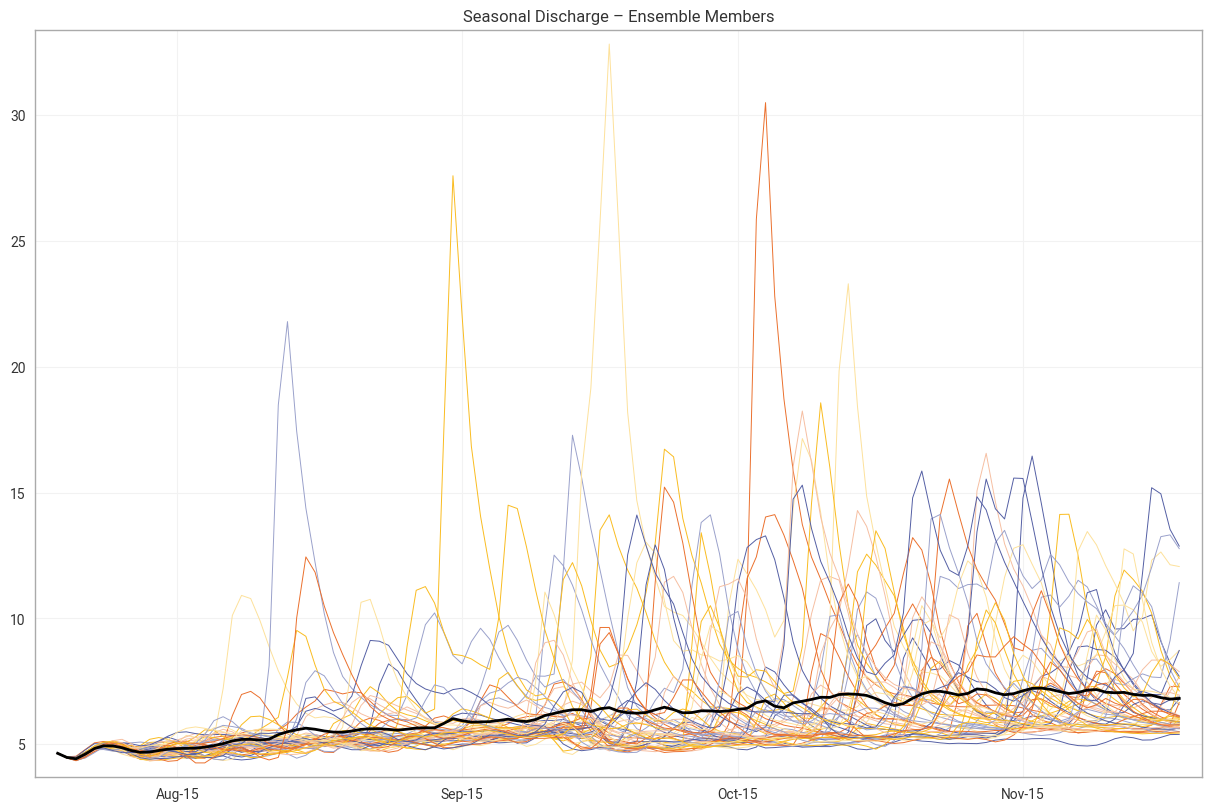

In [23]:
ds = data_array_single_point
ds1=ekh.transforms.ensemble.mean(data_array_single_point)
fig = ekh.plots.Figure(rows=1, columns=1, size=(12, 8))
sp = fig.add_subplot(0, 0)

data = ds["dis24"]  
time = ds["valid_time"]

data_mean = ds1["dis24"]  
time_mean = ds1["valid_time"]
for n in ds["number"].values:
    member = data.sel(number=n)   # dims: (valid_time,)
    sp.line(
        x=time.values,
        y=member.values,
        linewidth=0.7,
        
    )

sp.line(
    x=time_mean.values,
        y=data_mean.values,
        linewidth=2,
    color='black',
)    

sp.legend
sp.title("Seasonal Discharge – Ensemble Members")
sp.set_major_xticks(frequency="M", format="%b-%d")

fig.show()


In [25]:
ds1=ekh.transforms.ensemble.mean(data_array_single_point)
print(ds1)

<xarray.Dataset> Size: 2kB
Dimensions:     (valid_time: 123)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 984B 2024-08-02 ... 2024-12-02
    latitude    float64 8B 39.18
    longitude   float64 8B -1.425
Data variables:
    dis24       (valid_time) float64 984B 4.639 4.475 4.42 ... 6.852 6.792 6.82
Attributes: (12/14)
    param:        dis24
    paramId:      240024
    class:        ce
    stream:       wfse
    levtype:      sfc
    type:         fc
    ...           ...
    time:         0
    anoffset:     0
    origin:       ecmf
    domain:       g
    Conventions:  CF-1.8
    institution:  ECMWF


## Soil wetness index


In [ ]:
DATASET = 'cems-glofas-seasonal'
LEADTIMES = ['%d' % (l) for l in range(24, 2976, 24)]
REQUEST = {
    'system_version': ['operational'],
    "hydrological_model": ["lisflood"],
    'variable': 'soil_wetness_index',
    'year': ["2024"],
    'month': ["08"],
    'leadtime_hour': LEADTIMES,
    'area': [43.79, -9.30, 36.00, 3.33],
    'data_format': 'grib2', # Or netcdf
    'download_format': 'unarchived'
        }
data=ekh.data.from_source('cds',DATASET,REQUEST)

In [30]:
SWI = ekh.data.from_source("file","/perm/ecm3644/ecmwf-training/WMO-Seasonal/seasonal-data-spain/SWI/cems-glofas-seasonal_2024_08_SWI.grib")

In [31]:
SWI.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
0,ecmf,swir,rootZone,0,20240801,0,24,fc,0,regular_ll
1,ecmf,swir,rootZone,0,20240801,0,24,fc,1,regular_ll
2,ecmf,swir,rootZone,0,20240801,0,24,fc,2,regular_ll
3,ecmf,swir,rootZone,0,20240801,0,24,fc,3,regular_ll
4,ecmf,swir,rootZone,0,20240801,0,24,fc,4,regular_ll
...,...,...,...,...,...,...,...,...,...,...
6268,ecmf,swir,rootZone,0,20240801,0,2952,fc,46,regular_ll
6269,ecmf,swir,rootZone,0,20240801,0,2952,fc,47,regular_ll
6270,ecmf,swir,rootZone,0,20240801,0,2952,fc,48,regular_ll
6271,ecmf,swir,rootZone,0,20240801,0,2952,fc,49,regular_ll


In [41]:
SWI_array=SWI.to_xarray(engine='earthkit',time_dim_mode="valid_time")
print(SWI_array)
SWI_array_transform=ekh.transforms.temporal.monthly_reduce(SWI_array,time_dim='valid_time')
SWI_array_transform_ensemble=ekh.transforms.ensemble.mean(SWI_array_transform)

<xarray.Dataset> Size: 2GB
Dimensions:     (number: 51, valid_time: 123, latitude: 156, longitude: 253)
Coordinates:
  * number      (number) int64 408B 0 1 2 3 4 5 6 7 ... 43 44 45 46 47 48 49 50
  * valid_time  (valid_time) datetime64[ns] 984B 2024-08-02 ... 2024-12-02
  * latitude    (latitude) float64 1kB 43.77 43.73 43.68 ... 36.13 36.08 36.02
  * longitude   (longitude) float64 2kB -9.275 -9.225 -9.175 ... 3.275 3.325
Data variables:
    swir        (number, valid_time, latitude, longitude) float64 2GB ...
Attributes: (12/14)
    param:        swir
    paramId:      231026
    class:        ce
    stream:       wfse
    levtype:      sfc
    type:         fc
    ...           ...
    time:         0
    anoffset:     0
    origin:       ecmf
    domain:       g
    Conventions:  CF-1.8
    institution:  ECMWF


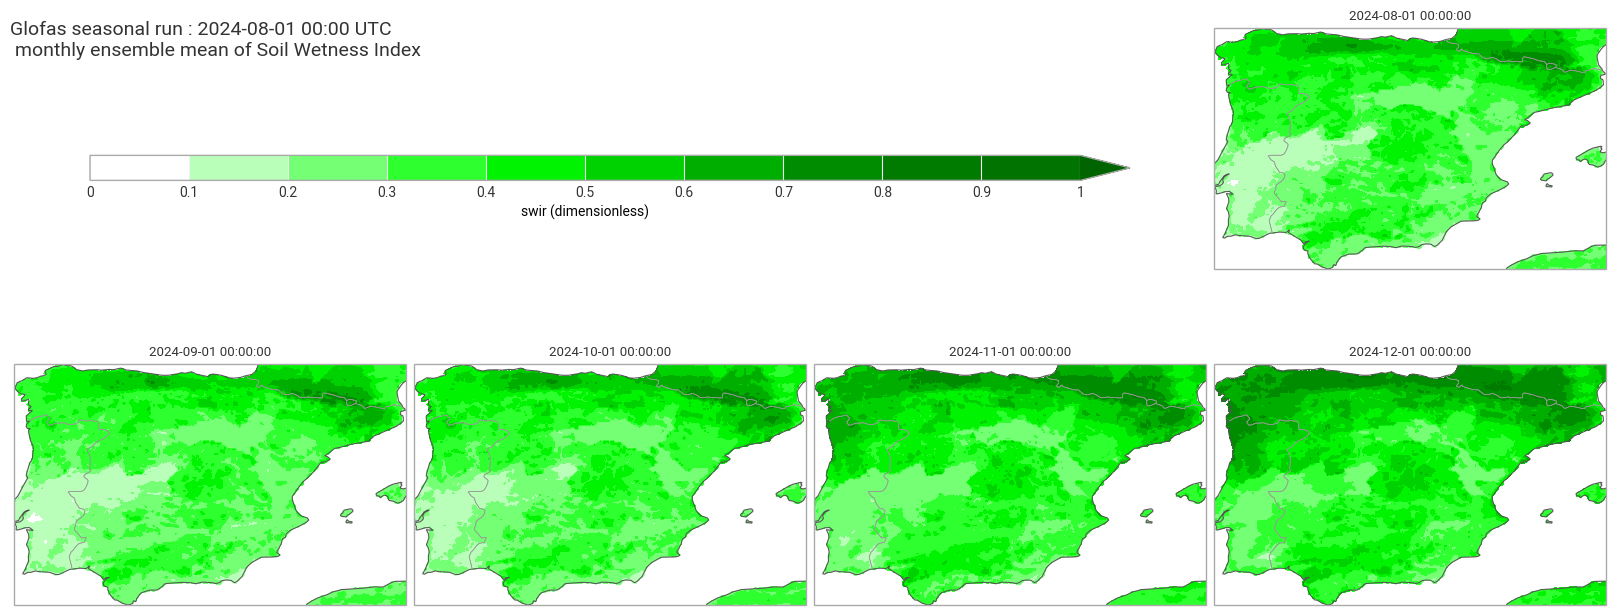

In [50]:
figure = ekh.plots.Figure(rows=3, columns=4,size=(16, 10))

figure.add_map(0, 3)
for i in range(4):
    figure.add_map(1+i//4, i%4)

figure.quickplot(SWI_array_transform_ensemble['swir'],auto_style=True)



figure.land()
figure.coastlines()
figure.borders()


ax = plt.axes((0.05, 0.8, 0.65, 0.025))
figure.legend(ax=ax)
figure.subplot_titles("{valid_time}")
figure.title(
    "Glofas seasonal run : 2024-08-01 00:00 UTC\n monthly ensemble mean of Soil Wetness Index",
    fontsize=14, horizontalalignment="left", x=0, y=0.96,
)
figure.show()